<a href="https://colab.research.google.com/github/ThamyresBrasil82/meu-portfolio/blob/main/Avengers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Avengers**

## 1 - Descrição Geral do Problema

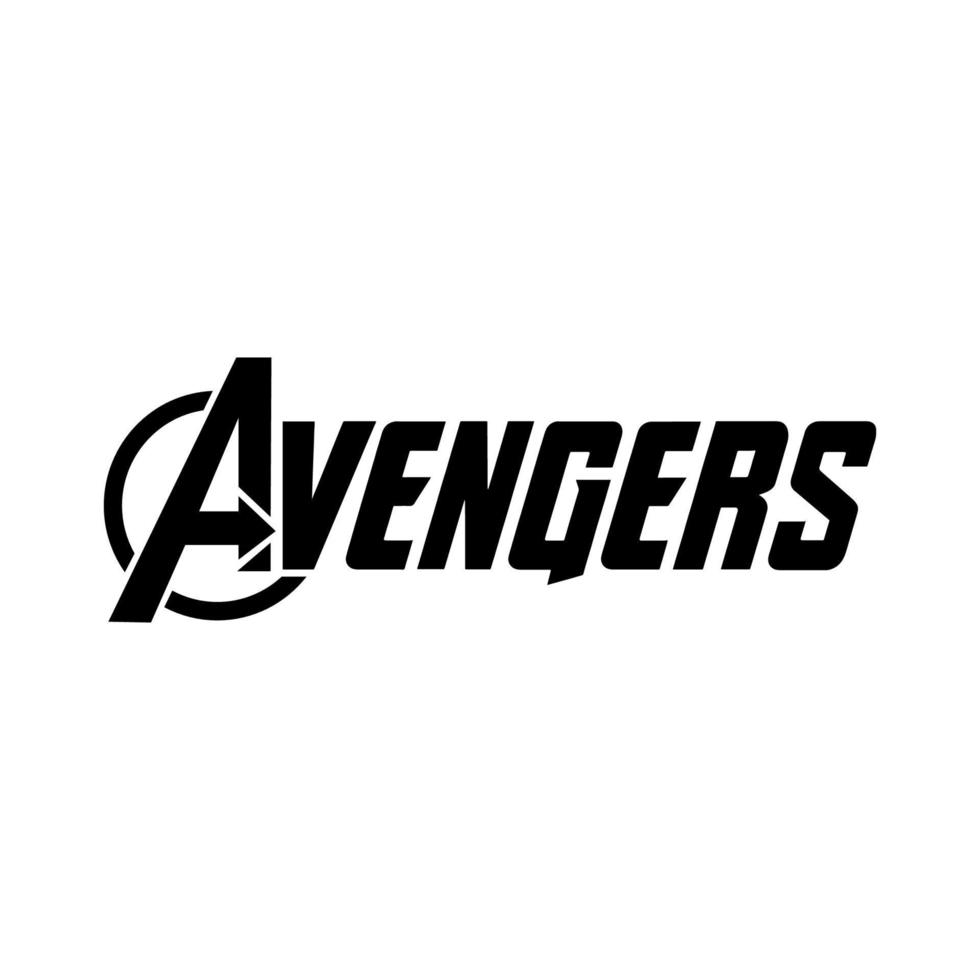

O universo dos Vingadores da Marvel é vasto e repleto de personagens
icônicos. Ao longo dos anos, diferentes heróis entraram e saíram da
equipe, protagonizando eventos marcantes que moldaram a história desse grupo lendário.


Analisar os dados relacionados a esses personagens pode revelar padrões interessantes e curiosidades sobre a formação, evolução e diversidade da equipe ao longo do tempo.


Este conjunto de dados contém informações detalhadas sobre os membros dos Vingadores, incluindo nome ou alias, número de aparições em quadrinhos, gênero, ano de entrada no grupo, status atual (ativo ou inativo), e dados sobre possíveis mortes e retornos. Com essas variáveis, é possível investigar questões como frequência de participação dos personagens, mudanças na composição da equipe ao longo dos anos e representatividade de gênero.


Através da análise desse conjunto de dados, é possível não apenas entender a evolução dos Vingadores como equipe, mas também explorar como o universo Marvel se desenvolveu ao longo das décadas. Questões de diversidade, longevidade dos personagens, ciclos narrativos e até mesmo estratégias editoriais podem ser levantadas a partir dessas informações. Além disso, esse tipo de análise une o entretenimento à Análise de dados, tornando o aprendizado mais envolvente e aplicável a contextos da cultura pop.

# 2-Carregando Dados

Começaremos nosso projeto, importanto todas as bilbiotecas necessárias, para a realização das fases iniciais de exploração, e transformação dos dados

In [ ]:
#importando biblioteca
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

plt.style.use("ggplot")



In [ ]:
from google.colab import files
uploaded = files.upload()


Saving avengers.csv to avengers.csv


In [ ]:
#Carregando os dados
df = pd.read_csv('avengers.csv', encoding='ISO-8859-1')

# 3-Preparando dados para a análise exploratória

In [ ]:
#exibir primeiras linhas
df.head(5)

,URL,Name/Alias,Appearances,Current?,Gender,Probationary Introl,Full/Reserve Avengers Intro,Year,Years since joining,Honorary,...,Return1,Death2,Return2,Death3,Return3,Death4,Return4,Death5,Return5,Notes
0,http://marvel.wikia.com/Henry_Pym_(Earth-616),"Henry Jonathan ""Hank"" Pym",1269,YES,MALE,NaN,Sep-63,1963,52,Full,...,NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Merged with Ultron in Rage of Ultron Vol. 1. A...
1,http://marvel.wikia.com/Janet_van_Dyne_(Earth-...,Janet van Dyne,1165,YES,FEMALE,NaN,Sep-63,1963,52,Full,...,YES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dies in Secret Invasion V1:I8. Actually was se...
2,http://marvel.wikia.com/Anthony_Stark_(Earth-616),"Anthony Edward ""Tony"" Stark",3068,YES,MALE,NaN,Sep-63,1963,52,Full,...,YES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Death: ""Later while under the influence of Imm..."
3,http://marvel.wikia.com/Robert_Bruce_Banner_(E...,Robert Bruce Banner,2089,YES,MALE,NaN,Sep-63,1963,52,Full,...,YES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Dies in Ghosts of the Future arc. However ""he ..."
4,http://marvel.wikia.com/Thor_Odinson_(Earth-616),Thor Odinson,2402,YES,MALE,NaN,Sep-63,1963,52,Full,...,YES,YES,NO,NaN,NaN,NaN,NaN,NaN,NaN,Dies in Fear Itself brought back because that'...


In [ ]:
# numero de linhas e colunas
df.shape

(173, 21)

Verificamos a existência de **21 váriaveis**, e **173 observações** dentro do dataset

In [ ]:
# Mostra informações
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173 entries, 0 to 172
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   URL                          173 non-null    object
 1   Name/Alias                   163 non-null    object
 2   Appearances                  173 non-null    int64 
 3   Current?                     173 non-null    object
 4   Gender                       173 non-null    object
 5   Probationary Introl          15 non-null     object
 6   Full/Reserve Avengers Intro  159 non-null    object
 7   Year                         173 non-null    int64 
 8   Years since joining          173 non-null    int64 
 9   Honorary                     173 non-null    object
 10  Death1                       173 non-null    object
 11  Return1                      69 non-null     object
 12  Death2                       17 non-null     object
 13  Return2                      16 non

In [ ]:
#Verificando o número de registro duplicados.

df.duplicated().sum()

np.int64(0)

**Não há registros duplicados** dentro do conjunto de dados.

In [ ]:
# Verificando o número de NAs existentes dentro do dataset.

df.isna().sum()

,0
URL,0
Name/Alias,10
Appearances,0
Current?,0
Gender,0
Probationary Introl,158
Full/Reserve Avengers Intro,14
Year,0
Years since joining,0
Honorary,0


# Convertendo variável

In [ ]:
df['Return1']= df['Return1'].fillna('no')

In [ ]:
df[['Death1','Return1']]= df[['Death1','Return1']].replace({'yes':1,'no':0})

In [ ]:
#quantidade de herois
df['Name/Alias'].nunique()

162

# 4-Análise exploratória dos dados

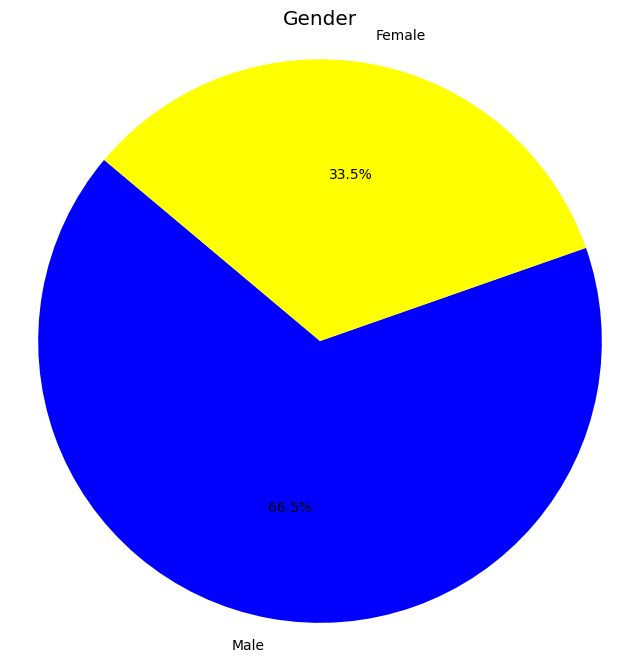

In [ ]:
#Genero
df_counts = df['Gender'].value_counts()
label = ["Male","Female"]
color=['blue','yellow']

#plotando um gráfico de pizza

plt.figure(figsize=(8,8))
plt.pie(df_counts,labels=label,colors=color,autopct='%1.1f%%', startangle=140)
plt.title("Gender")
plt.axis('equal')
plt.show()


**33,5 são do sexo Feminino** e **66,5 são do sexo masculino.**

In [ ]:
#media que os personagens aparecem
mean_avengers=df['Appearances'].mean()
print(mean_avengers)

414.05202312138726


Em média, os personagens aparecem em **414,05**.

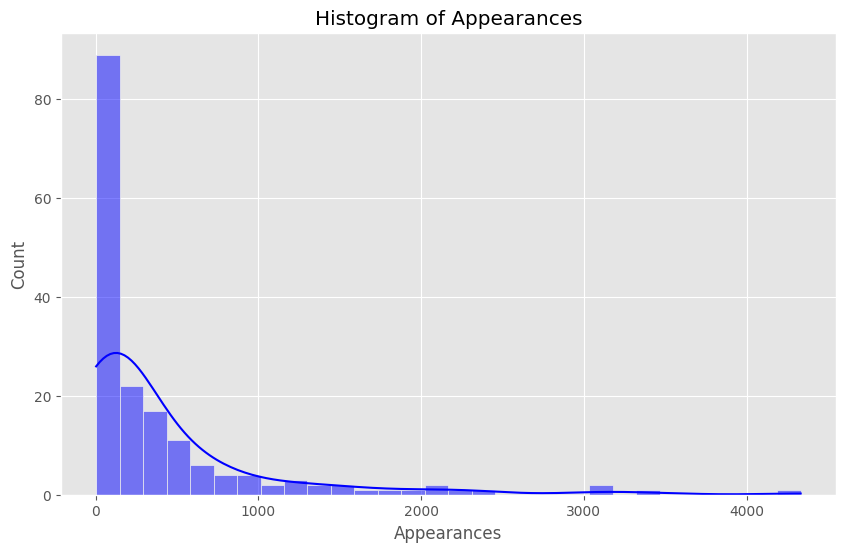

In [ ]:
#plotando histograma

plt.figure(figsize=(10,6))
sns.histplot(df['Appearances'].dropna(),bins=30,kde=True , color='blue')
plt.title('Histogram of Appearances')
plt.xlabel('Appearances')
plt.ylabel('Count')
plt.show()



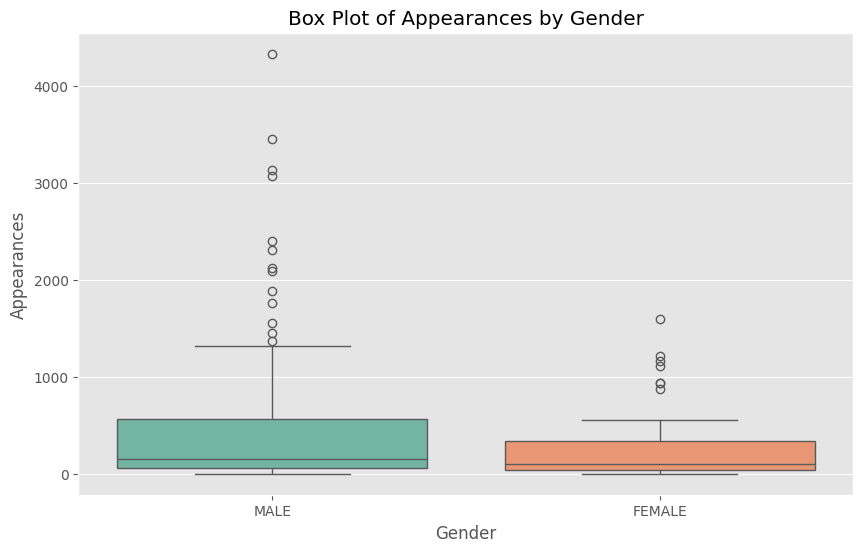

In [ ]:
#box plot genero por aparecer
plt.figure(figsize=(10,6))
sns.boxplot(x='Gender',y='Appearances',data=df, palette='Set2')
plt.title('Box Plot of Appearances by Gender')
plt.xlabel('Gender')
plt.ylabel('Appearances')
plt.show()


Os personagens masculinos dominam a cena, com uma quantidade muito maior de aparições do que suas contrapartes femininas. Além disso, a presença de outliers expressivos nos dados dos personagens masculinos destaca a existência de alguns heróis com um número extraordinariamente alto de aparições, amplificando ainda mais essa diferença.

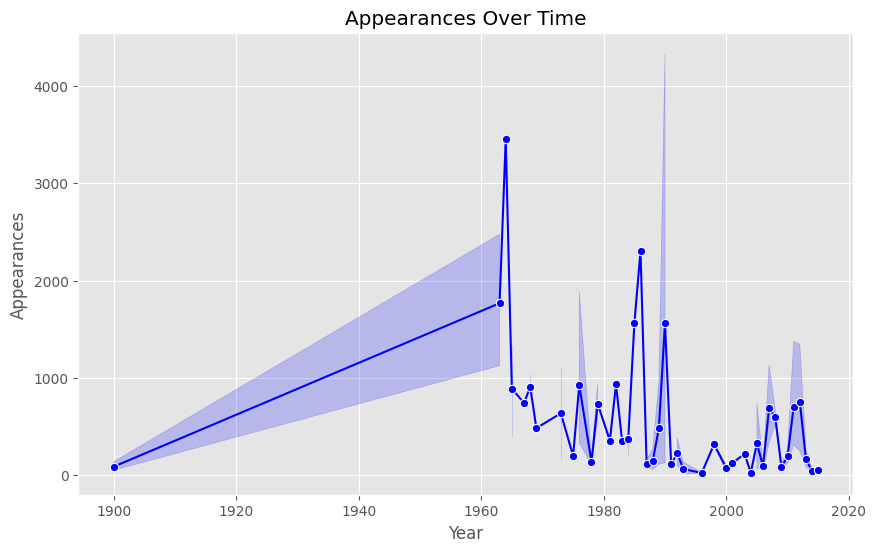

In [ ]:
#Criando o gráfico de linhas

plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='Year', y='Appearances',color='blue',marker='o')
plt.title('Appearances Over Time')
plt.xlabel('Year')
plt.ylabel('Appearances')
plt.grid(True)
plt.show()

Como a Marvel foi criada em 1939, aplicamos um filtro para considerar apenas os anos a partir desse marco na análise.

In [ ]:
df_filtrado = df[df['Year'] >= 1939]

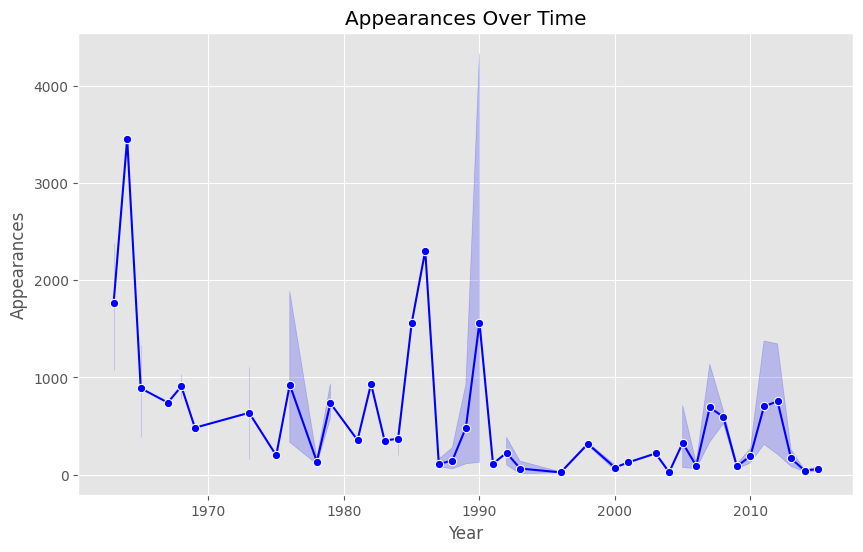

In [ ]:
#Criando o gráfico de linhas filtrado

plt.figure(figsize=(10,6))
sns.lineplot(data=df_filtrado, x='Year', y='Appearances',color='blue',marker='o')
plt.title('Appearances Over Time')
plt.xlabel('Year')
plt.ylabel('Appearances')
plt.grid(True)
plt.show()

Agora podemos visualizar com mais clareza como o número de aparições dos personagens.

In [ ]:
#Trocar de Anos para decadas

df['Decade']=(df['Year'] //10)*10

In [ ]:
df_decade_gender = df.groupby(['Decade', 'Gender'])['Name/Alias'].count().reset_index(name='Count')

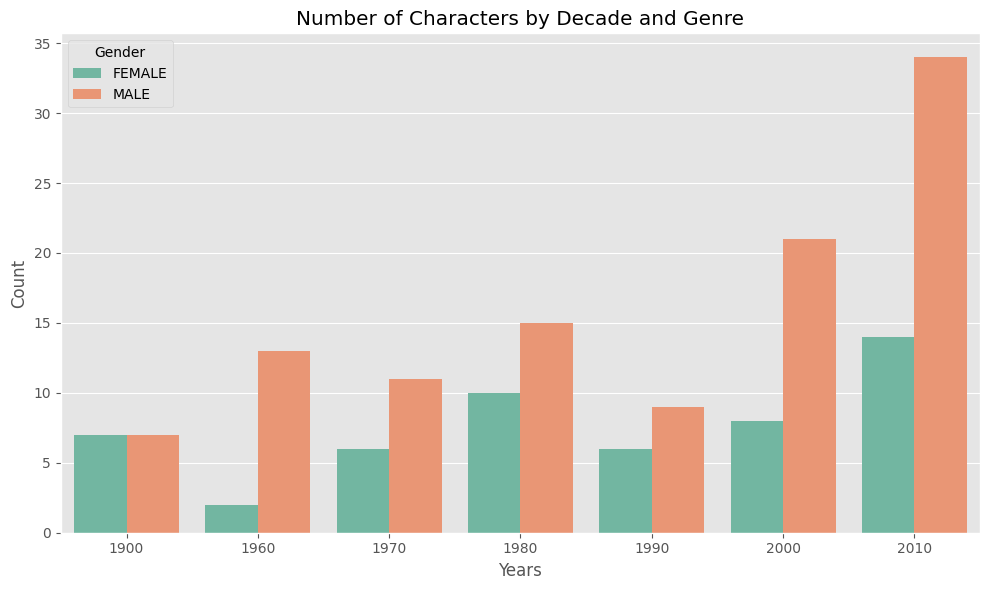

In [ ]:
#Criar grafico de barras
plt.figure(figsize=(10,6))
sns.barplot(data=df_decade_gender, x='Decade', y='Count', hue='Gender', palette='Set2')
plt.title('Number of Characters by Decade and Genre')
plt.xlabel('Years')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

Podemos observar que o número de personagens vinha em uma tendência de crescimento até a década de 1990, quando houve uma queda. No entanto, na década de 2000, esse número voltou a crescer com força, e em 2010 já havia superado todas as décadas anteriores.

In [ ]:
# Tabela de Frequência
frequencia_relativa=pd.crosstab(df['Gender'], df['Honorary'], normalize='index')*100
frequencia_relativa.round(2).astype(str) + '%'

Honorary,Academy,Full,Honorary,Probationary
Gender,,,,
FEMALE,15.52%,74.14%,10.34%,0.0%
MALE,6.96%,82.61%,8.7%,1.74%




Plenos dominam em ambos os gêneros. Mulheres têm maior representatividade na categoria Academy e também aparecem ligeiramente mais entre os Honorários. Apenas homens estão na categoria Probatória.

In [ ]:
# Definindo os rótulos dos quartis
quartile_labels = ['Q1','Q2','Q3','Q4']

# Crianda a nova coluna
df['quartis'] = pd.qcut(df['Appearances'], q=4, labels=quartile_labels)

# Exibir as primeiras linhas com a nova coluna

df[['Appearances','quartis']].head(20)

,Appearances,quartis
0,1269,Q4
1,1165,Q4
2,3068,Q4
3,2089,Q4
4,2402,Q4
5,612,Q4
6,3458,Q4
7,1456,Q4
8,769,Q4
9,1214,Q4


In [ ]:
# Criar coluna binária
df['morte'] = df['Death1'].apply(lambda x: 1 if x == 'YES' else 0)

In [ ]:
df[['morte','Death1']].head(10)

,morte,Death1
0,1,YES
1,1,YES
2,1,YES
3,1,YES
4,1,YES
5,0,NO
6,1,YES
7,1,YES
8,1,YES
9,1,YES


In [ ]:
# Agrupar por quartil e calcular a média
media_de_mortes_quartil = df.groupby('quartis')['morte'].mean()*100

# Exibir os resultados
print(media_de_mortes_quartil)

quartis
Q1    31.818182
Q2    31.818182
Q3    47.619048
Q4    48.837209
Name: morte, dtype: float64


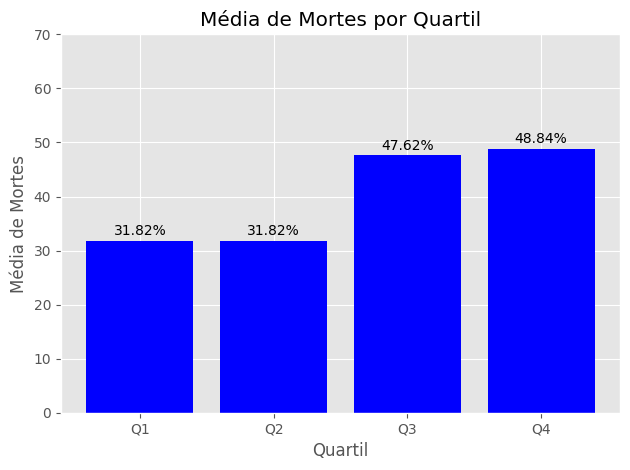

In [ ]:
#Criar gráfico de barras
plt.bar(media_de_mortes_quartil.index, media_de_mortes_quartil.values , color='blue')
plt.ylim(0, 70)
plt.xlabel('Quartil')
plt.ylabel('Média de Mortes')
plt.title('Média de Mortes por Quartil')
for i, valor in enumerate(media_de_mortes_quartil.values):
    plt.text(i, valor + 1, f'{valor:.2f}%', ha='center')
plt.tight_layout()
plt.show()


Dividi os personagens em quatro grupos, do que apresenta menor média de mortes até o que apresenta a maior. Um quarto deles (25%) tem uma média baixa de mortes, em torno de 31%. A maior parte dos personagens fica em uma faixa intermediária, com médias de até 47%. Já os 25% finais são os que têm as maiores médias de mortes nas histórias.

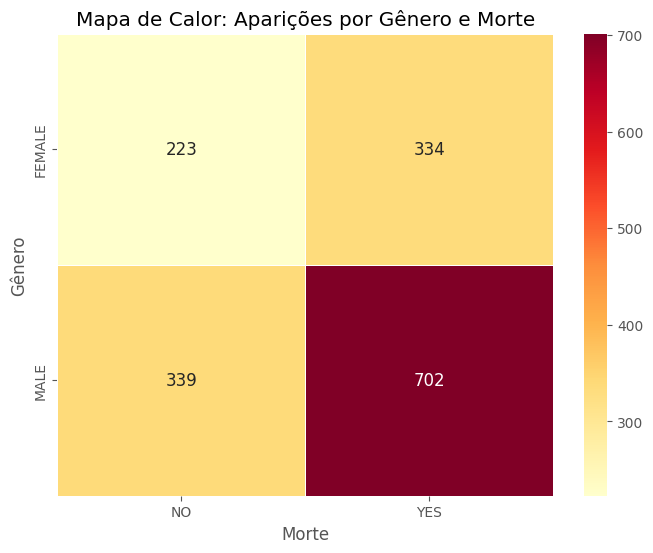

In [ ]:
# Agrupar pela média de aparições por gênero e tipo de morte
agrupado = df.groupby(['Gender', 'Death1'])['Appearances'].mean().reset_index()

# Reorganizar a tabela para formato de matriz
tabela = agrupado.pivot(index='Gender', columns='Death1', values='Appearances')


plt.figure(figsize=(8, 6))
sns.heatmap(tabela, annot=True, fmt=".0f", cmap='YlOrRd', linewidths=0.5, annot_kws={"size": 12})

plt.title('Mapa de Calor: Aparições por Gênero e Morte')
plt.xlabel('Morte')
plt.ylabel('Gênero')
plt.show()

O grupo de personagens masculinos que tiveram a primeira morte registrou a maior média de aparições, com 702. Isso indica que, mesmo morrendo, esses personagens estavam muito presentes na narrativa. O que pode sugerir que são personagens importantes ou centrais na história.



## **Conclusão**



Ao analisar os dados dos personagens dos Vingadores, conseguimos entender melhor como esse grupo tão famoso foi se formando e mudando ao longo dos anos.

Vimos que a maioria dos heróis é do gênero masculino e que, em média, eles aparecem muito mais nas histórias do que as mulheres. Também percebemos que, mesmo quando os personagens masculinos morrem, eles ainda são os que mais aparecem, isso pode mostrar que muitos deles têm papéis importantes ou marcantes nas tramas.

Quando dividimos os personagens em grupos, vimos que aqueles com mais aparições tendem a ter também uma média de mortes maior. Isso mostra que os personagens mais presentes nas histórias são, muitas vezes, os que passam por mais reviravoltas, incluindo mortes e retornos.

Essas informações ajudam a entender não só a história dos Vingadores, mas também como os quadrinhos refletem certos padrões: quem tem mais destaque, quem sofre mais mudanças, e como isso foi evoluindo com o tempo. É uma forma divertida de usar os dados para contar a história por trás das histórias.